In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the data
# You can change 'train' to 'train+prompt', 'generate_ss', or 'generate_qa' based on what you want to analyze
vector_type = "train"
model_short_name = "mistral"
csv_path = f"../data/vector_similarities/{model_short_name}/{vector_type}_cosine_similarities.csv"

df = pd.read_csv(csv_path)


In [3]:
# -------------------------------------------------------------------
# Table: Finding the most correlated and anti-correlated pairs overall
# -------------------------------------------------------------------
print(f"--- Top 10 Most Correlated Pairs ({vector_type}) ---")
top_correlated = df.sort_values(by="cosine_similarity", ascending=False).head(10)
display(top_correlated[['layer', 'axis_1', 'axis_2', 'cosine_similarity']])

print(f"\n--- Top 10 Most Anti-Correlated Pairs ({vector_type}) ---")
top_anticorrelated = df.sort_values(by="cosine_similarity", ascending=True).head(10)
display(top_anticorrelated[['layer', 'axis_1', 'axis_2', 'cosine_similarity']])

--- Top 10 Most Correlated Pairs (train) ---


,layer,axis_1,axis_2,cosine_similarity
30,1,race,religion,0.998133
1,1,age,disability,0.997835
24,1,gender,socioeconomic,0.997517
10,1,appearance,nationality,0.996395
27,1,nationality,religion,0.995656
17,1,disability,race,0.995417
66,2,race,religion,0.995193
0,1,age,appearance,0.994791
18,1,disability,religion,0.993711
46,2,appearance,nationality,0.993590



--- Top 10 Most Anti-Correlated Pairs (train) ---


,layer,axis_1,axis_2,cosine_similarity
6,1,age,socioeconomic,-0.998505
19,1,disability,socioeconomic,-0.997952
15,1,disability,gender,-0.997913
22,1,gender,race,-0.996667
23,1,gender,religion,-0.996404
2,1,age,gender,-0.996382
9,1,appearance,gender,-0.995985
13,1,appearance,socioeconomic,-0.995548
21,1,gender,nationality,-0.995054
31,1,race,socioeconomic,-0.994489


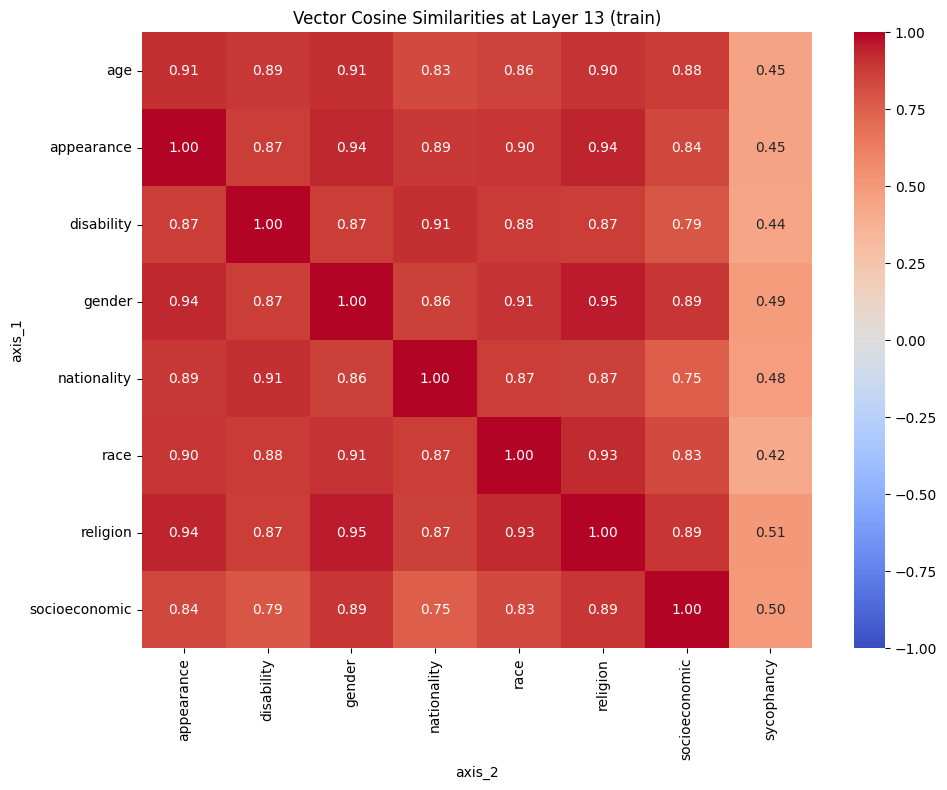

: 

In [ ]:
# -------------------------------------------------------------------
# Heatmap: Visualizing all axis relationships at a specific layer
# -------------------------------------------------------------------
# You can change this to any layer number you're interested in (e.g., 5, 10, 20)
target_layer = 13
layer_df = df[df['layer'] == target_layer]

if not layer_df.empty:
    # Pivot the data to create a symmetric matrix for the heatmap
    pivot_df = layer_df.pivot(index='axis_1', columns='axis_2', values='cosine_similarity')
    
    # Fill in the mirror image of the matrix and set diagonals to 1.0
    for ax1 in pivot_df.index:
        for ax2 in pivot_df.columns:
            if pd.isna(pivot_df.loc[ax1, ax2]):
                if ax1 == ax2:
                    pivot_df.loc[ax1, ax2] = 1.0
                elif ax1 in pivot_df.columns and ax2 in pivot_df.index:
                     pivot_df.loc[ax1, ax2] = pivot_df.loc[ax2, ax1]

    plt.figure(figsize=(10, 8))
    sns.heatmap(pivot_df, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, fmt=".2f")
    plt.title(f"Vector Cosine Similarities at Layer {target_layer} ({vector_type})")
    plt.tight_layout()
    plt.show()
else:
    print(f"\nNo data found for layer {target_layer}.")


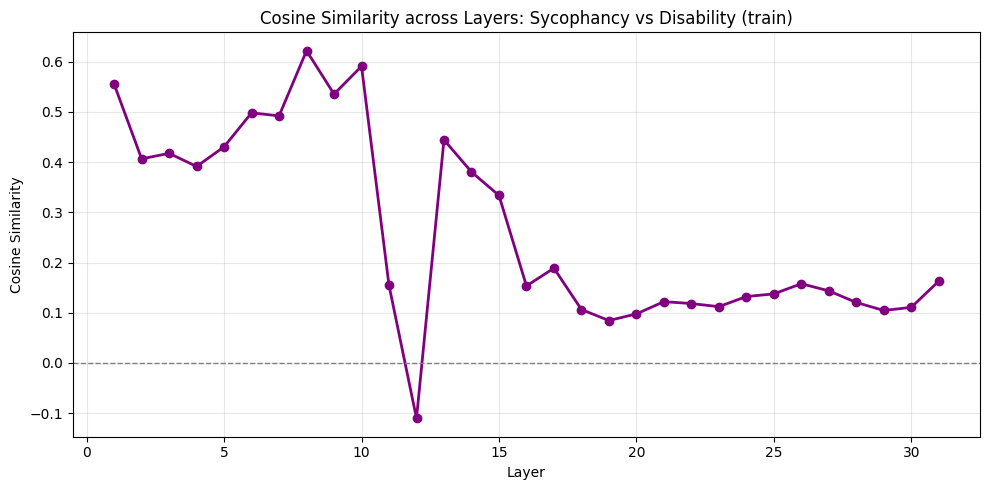

: 

In [ ]:
# -------------------------------------------------------------------
# Line Graph: Tracking the relationship of a specific pair across layers
# -------------------------------------------------------------------
# Change these to whichever two axes you want to compare
axis_a = "sycophancy"
axis_b = "disability"

# Filter for tests that matched our sequence (A vs B) or the reverse (B vs A)
pair_df = df[((df['axis_1'] == axis_a) & (df['axis_2'] == axis_b)) | 
             ((df['axis_1'] == axis_b) & (df['axis_2'] == axis_a))]

if not pair_df.empty:
    pair_df = pair_df.sort_values(by='layer')
    
    plt.figure(figsize=(10, 5))
    plt.plot(pair_df['layer'], pair_df['cosine_similarity'], marker='o', linewidth=2, color='purple')
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    
    plt.title(f"Cosine Similarity across Layers: {axis_a.capitalize()} vs {axis_b.capitalize()} ({vector_type})")
    plt.xlabel("Layer")
    plt.ylabel("Cosine Similarity")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"\nNo comparison found between {axis_a} and {axis_b}.")